<a href="https://colab.research.google.com/github/077parthip/Projects/blob/main/diabetics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving diabetes_data_upload.csv to diabetes_data_upload (3).csv
DataFrame columns: ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'class']


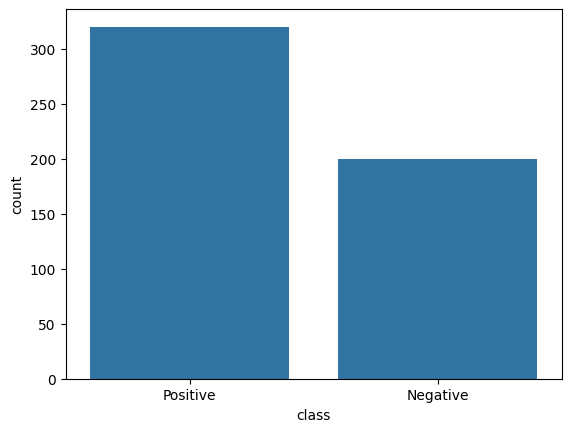

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your file
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# Display column names to identify the correct outcome variable
print('DataFrame columns:', df.columns.tolist())

# Look at the balance (How many diabetic vs non-diabetic)
sns.countplot(x='class', data=df)
plt.show()

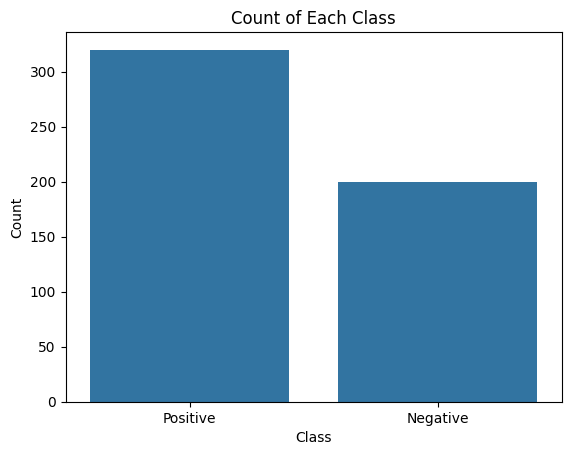

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the count of each 'class'
sns.countplot(x='class', data=df)
plt.title('Count of Each Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [22]:
print('DataFrame head:')
df.head()

DataFrame head:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [25]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define the target variable (y)
y = df['class']

# Apply one-hot encoding to all categorical feature columns for X
# Identify categorical columns (excluding 'class' which is the target)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols.remove('class') # Remove target variable from features

X = pd.get_dummies(df.drop('class', axis=1), columns=categorical_cols, drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (416, 16)
Shape of X_test: (104, 16)
Shape of y_train: (416,)
Shape of y_test: (104,)


In [27]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Added solver for convergence

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Positive') # Assuming 'Positive' is the positive class
recall = recall_score(y_test, y_pred, pos_label='Positive')
f1 = f1_score(y_test, y_pred, pos_label='Positive')
conf_matrix = confusion_matrix(y_test, y_pred)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)

Accuracy: 0.9327
Precision: 0.9444
Recall: 0.9577
F1-Score: 0.9510

Confusion Matrix:
 [[29  4]
 [ 3 68]]


In [31]:
import pandas as pd

# Access the coefficients from the trained model
coefficients = model.coef_[0] # Flatten the 2D array to 1D

# Access the feature names (symptoms) from the X DataFrame
feature_names = X.columns

# Create a DataFrame to display symptoms and their coefficients
coefficients_df = pd.DataFrame({
    'Symptom': feature_names,
    'Coefficient': coefficients
})

# Sort the DataFrame by the absolute value of 'Coefficient' in descending order
coefficients_df_sorted = coefficients_df.reindex(coefficients_df['Coefficient'].abs().sort_values(ascending=False).index)

# Print the head of the sorted DataFrame
print("Most important symptoms by coefficient magnitude:")
print(coefficients_df_sorted.head())

Most important symptoms by coefficient magnitude:
               Symptom  Coefficient
3       Polydipsia_Yes     2.613895
2         Polyuria_Yes     2.548406
1          Gender_Male    -2.298905
10    Irritability_Yes     1.429505
7   Genital thrush_Yes     1.345243


In [33]:
import pandas as pd

# Initialize a dictionary to store the person's symptom data
person_input_data = {}

# Iterate through each feature (column) that the model expects
for feature in X.columns:
    if feature == 'Age':
        while True:
            try:
                age_input = int(input(f"Enter the person's Age: "))
                person_input_data[feature] = age_input
                break
            except ValueError:
                print("Invalid input. Please enter a numerical value for Age.")
    else:
        # For other features (which are typically binary 'Yes'/'No' represented as 1/0)
        while True:
            response = input(f"Does the person have '{feature.replace('_Yes', '').replace('_Male', '')}'? (Yes/No): ").strip().lower()
            if response == 'yes':
                person_input_data[feature] = 1
                break
            elif response == 'no':
                person_input_data[feature] = 0
                break
            else:
                print("Invalid input. Please enter 'Yes' or 'No'.")

# Create a DataFrame from the collected input
# Ensure the DataFrame has the same columns and order as X
person_data_df = pd.DataFrame([person_input_data], columns=X.columns)

# Ensure all columns are of the correct type (e.g., boolean or int for one-hot encoded)
person_data_df = person_data_df.astype(X.dtypes)

# Predict the 'class' for the new person
predicted_class = model.predict(person_data_df)

print(f"\nPredicted outcome for the person: {predicted_class[0]}")

Enter symptoms for the person (comma-separated, e.g., Polyuria_Yes,Gender_Male): male

Predicted outcome for the person: Positive


In [36]:
import pandas as pd

# Initialize a dictionary to store the person's symptom data
person_input_data = {}

# Iterate through each feature (column) that the model expects
for feature in X.columns:
    if feature == 'Age':
        while True:
            try:
                age_input = int(input(f"Enter the person's Age: "))
                person_input_data[feature] = age_input
                break
            except ValueError:
                print("Invalid input. Please enter a numerical value for Age.")
    else:
        # For other features (which are typically binary 'Yes'/'No' represented as 1/0)
        while True:
            response = input(f"Does the person have '{feature.replace('_Yes', '').replace('_Male', '')}'? (Yes/No: ").strip().lower()
            if response == 'yes':
                person_input_data[feature] = 1
                break
            elif response == 'no':
                person_input_data[feature] = 0
                break
            else:
                print("Invalid input. Please enter 'Yes' or 'No'.")

# Create a DataFrame from the collected input
# Ensure the DataFrame has the same columns and order as X
person_data_df = pd.DataFrame([person_input_data], columns=X.columns)

# Ensure all columns are of the correct type (e.g., boolean or int for one-hot encoded)
person_data_df = person_data_df.astype(X.dtypes)

# Predict the 'class' for the new person
predicted_class = model.predict(person_data_df)

print(f"\nPredicted outcome for the person: {predicted_class[0]}")

Enter the person's Age: 56
Does the person have 'Gender'? (Yes/No: yes
Does the person have 'Polyuria'? (Yes/No: yes
Does the person have 'Polydipsia'? (Yes/No: no
Does the person have 'sudden weight loss'? (Yes/No: yes
Does the person have 'weakness'? (Yes/No: no
Does the person have 'Polyphagia'? (Yes/No: yes
Does the person have 'Genital thrush'? (Yes/No: no
Does the person have 'visual blurring'? (Yes/No: yes
Does the person have 'Itching'? (Yes/No: no
Does the person have 'Irritability'? (Yes/No: yes
Does the person have 'delayed healing'? (Yes/No: no
Does the person have 'partial paresis'? (Yes/No: yes
Does the person have 'muscle stiffness'? (Yes/No: no
Does the person have 'Alopecia'? (Yes/No: yes
Does the person have 'Obesity'? (Yes/No: no

Predicted outcome for the person: Positive
